Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std = [0.229, 0.224, 0.225]
    )
])

Loading Dataset

In [4]:
train_dataset = datasets.Flowers102(
    root  = './data',
    split = 'train',
    download = True,
    transform = transform
)

val_dataset = datasets.Flowers102(
    root  = './data',
    split = 'val',
    download = True,
    transform = transform
)

test_dataset = datasets.Flowers102(
    root  = './data',
    split = 'test',
    download = True,
    transform = transform
)

In [5]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1020
1020
6149


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)

In [7]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Feature Extraction

In [8]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

In [9]:
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights= weights)

In [10]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Freezing Backbone Layers

In [11]:
for param in model.parameters():
    param.requires_grad = False

In [12]:
num_features = model.heads.head.in_features
model.heads.head = nn.Linear(num_features, 102)

In [13]:
model = model.to(device)

In [14]:
print(model.heads.head)

Linear(in_features=768, out_features=102, bias=True)


In [15]:
criterion = nn.CrossEntropyLoss()

In [16]:
optimizer = torch.optim.Adam(
    model.heads.head.parameters(),
    lr = 0.001
)

epochs = 10

In [18]:
train_losses = []
val_losses =[]

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total =0

    for images,labels in train_loader:
        images = images.to(device)
        labels= labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100* correct/total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images.labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted==labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct/total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Accuracy: {train_accuracy:.2f} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.2f} | "
          f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/10] | Train Accuracy: 22.35 | Train Loss: 4.0692 | Val Accuracy: 53.57 | Val Loss: 3.2367
Epoch [2/10] | Train Accuracy: 76.47 | Train Loss: 2.3560 | Val Accuracy: 75.00 | Val Loss: 2.0998
Epoch [3/10] | Train Accuracy: 88.43 | Train Loss: 1.4378 | Val Accuracy: 85.71 | Val Loss: 1.3912
Epoch [4/10] | Train Accuracy: 94.22 | Train Loss: 0.9389 | Val Accuracy: 100.00 | Val Loss: 0.7064
Epoch [5/10] | Train Accuracy: 97.25 | Train Loss: 0.6542 | Val Accuracy: 100.00 | Val Loss: 0.4402
Epoch [6/10] | Train Accuracy: 97.94 | Train Loss: 0.4831 | Val Accuracy: 96.43 | Val Loss: 0.5271
Epoch [7/10] | Train Accuracy: 99.22 | Train Loss: 0.3701 | Val Accuracy: 100.00 | Val Loss: 0.3367
Epoch [8/10] | Train Accuracy: 99.31 | Train Loss: 0.2918 | Val Accuracy: 100.00 | Val Loss: 0.2384
Epoch [9/10] | Train Accuracy: 99.61 | Train Loss: 0.2344 | Val Accuracy: 100.00 | Val Loss: 0.2237
Epoch [10/10] | Train Accuracy: 99.90 | Train Loss: 0.1921 | Val Accuracy: 100.00 | Val Loss: 0.1830


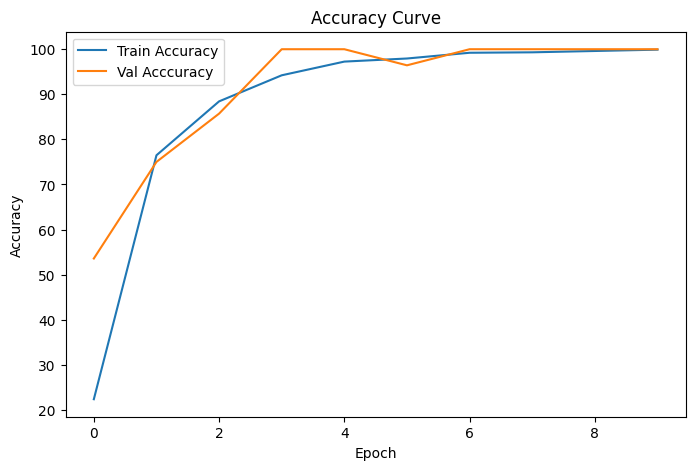

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Acccuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.show()

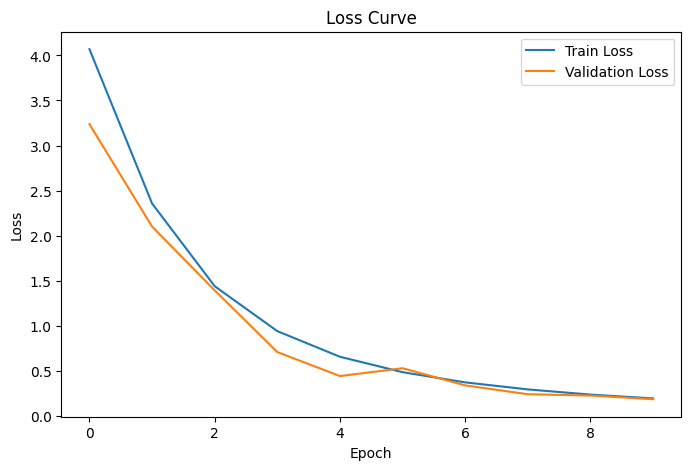

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.show()

In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy3 = 100 * correct / total

print("Test Accuracy:", test_accuracy3)

Test Accuracy: 82.69637339404781


In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds= []
all_labels= []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [26]:
cm= confusion_matrix(all_labels, all_preds)

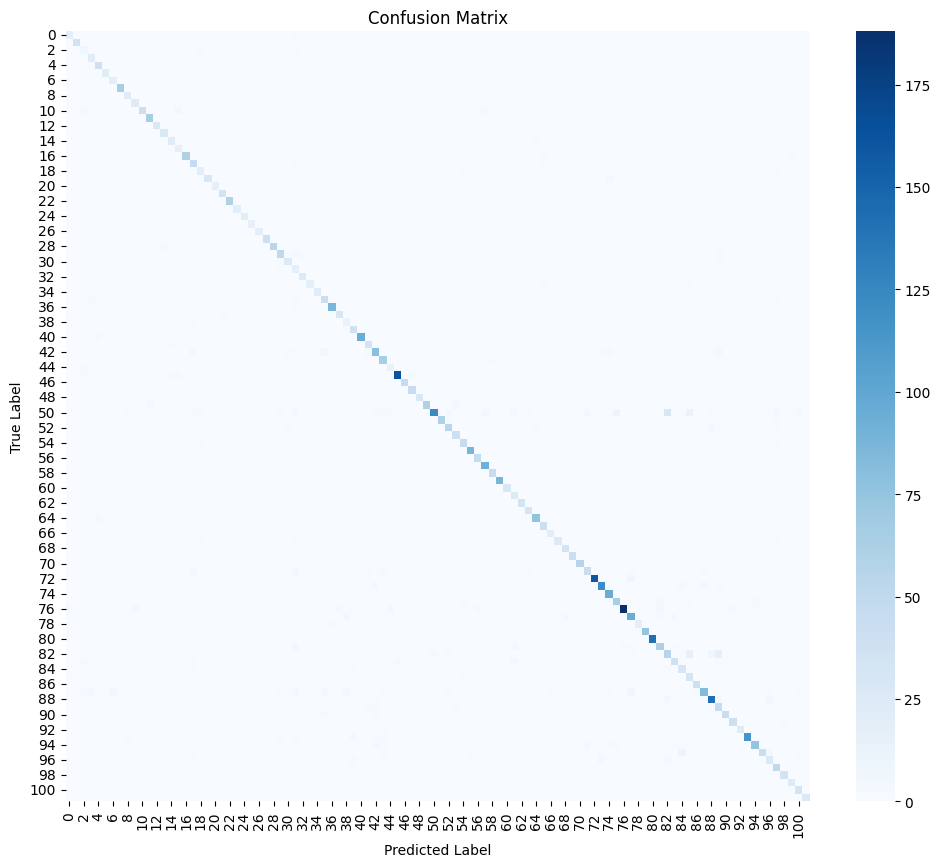

In [28]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()